new deformed j_list:
[1, 8, -10, 56, -190, 728, -2698, 10088, -37630, 140456, -524170, 1956248, -7300798, 27246968, -101687050, 379501256, -1416317950, 5285770568, -19726764298, 73621286648, -274758382270, 1025412242456, -3826890587530, 14282150107688, -53301709843198, 198924689265128, -742397047217290, 2770663499604056, -10340256951198910, 38590364305191608, -144021200269567498, 537494436773078408, -2005956546822746110, 7486331750517906056, -27939370455248878090, 104271150070477606328, -389145229826661547198, 1452309769236168582488, -5420093847118012782730, 20228065619235882548456, -75492168629825517411070, 281740608900066187095848, -1051470266970439230972298, 3924140458981690736793368, -14645091568956323716201150, 54656225816843604128011256, -203979811698418092795843850, 761263020976828767055364168, -2841072272208896975425612798, 10603026067858759134647087048]

new deformed h_list:
[1, 1, 9/2, 5/6, 497/24, -1213/40, 110041/720, -2214131/5040, 4285327/2688, -1941719023/362880, 6791881

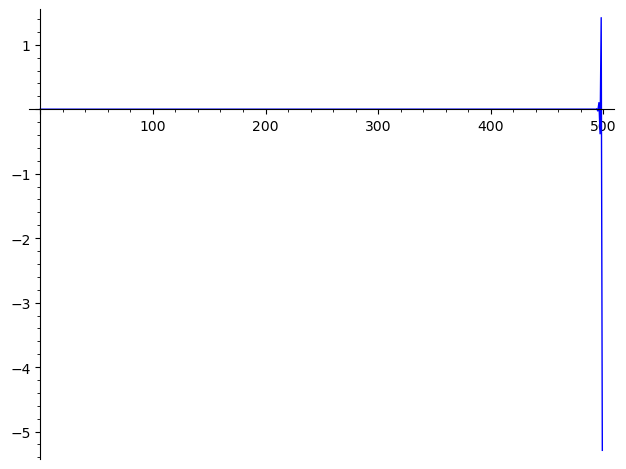

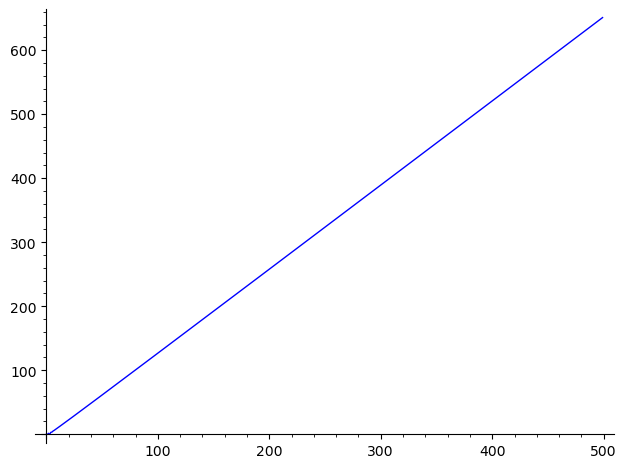

counts: (248, 0)


In [2]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j
    

h_list=[n**3 for n in range(1,500)]
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
print("new deformed j_list:")
print(deformed_j_list[:50])
print()
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("new deformed h_list:")
print(deformed_h_list[:50])
log_data=[]
zero_count=0
negative_count=0
for x in deformed_h_list:
    if x<0:
        negative_count+=1
    if x==0:
        zero_count+=1
    if x!=0:
        log_data.append(log(abs(x)))

p = list_plot(deformed_h_list, plotjoined=True, axes_labels=['', ''])
p.show()

p = list_plot(log_data, plotjoined=True, axes_labels=['', ''])
p.show()
print("counts:",(negative_count,zero_count))

new deformed j_list:
[1, 8, -10, 56, -190, 728, -2698, 10088, -37630, 140456, -524170, 1956248, -7300798, 27246968, -101687050, 379501256, -1416317950, 5285770568, -19726764298, 73621286648, -274758382270, 1025412242456, -3826890587530, 14282150107688, -53301709843198, 198924689265128, -742397047217290, 2770663499604056, -10340256951198910, 38590364305191608, -144021200269567498, 537494436773078408, -2005956546822746110, 7486331750517906056, -27939370455248878090, 104271150070477606328, -389145229826661547198, 1452309769236168582488, -5420093847118012782730, 20228065619235882548456, -75492168629825517411070, 281740608900066187095848, -1051470266970439230972298, 3924140458981690736793368, -14645091568956323716201150, 54656225816843604128011256, -203979811698418092795843850, 761263020976828767055364168, -2841072272208896975425612798, 10603026067858759134647087048]
n: 1 elapsed: 0.050752751032511395
n: 1
chi:
x - 1
n: 2 elapsed: 0.05077114899953206
n: 2
chi:
x^2 - 2*x + 9
n: 3 elapsed: 0.

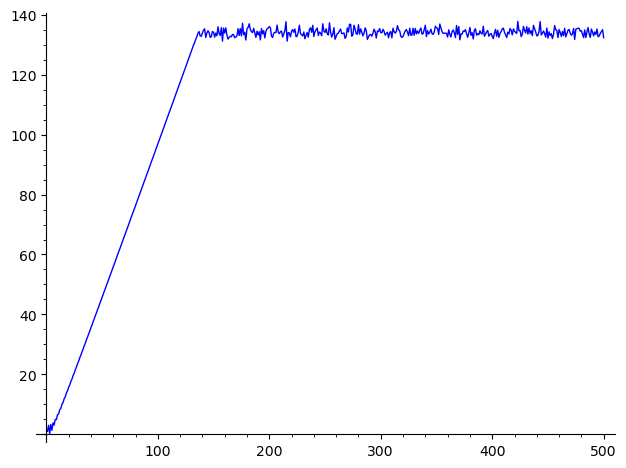

In [6]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

import matplotlib.pyplot as plt
import numpy as np

def signsNoGraphics(f, center, searchradius, grain):
    inc = searchradius / grain
    dta = []

    black = (0, 0, 0)
    green = (0, 1, 0)
    blue = (0, 0, 1)
    red = (1, 0, 0)
    yellow = (1, 1, 0)

    k = -searchradius - inc
    while k < searchradius:
        row = []
        j = -searchradius - inc
        while j < searchradius:
            w = CC(center + j + k * I)
            fw = f(w)
            u = real_part(fw)
            v = imag_part(fw)

            if u >= 0:
                if v >= 0:
                    shade = blue
                else:
                    shade = green
            else:
                if v >= 0:
                    shade = red
                else:
                    shade = yellow

            row.append(shade)
            j += inc
        dta.append(row)
        k += inc

    return dta

def plot_signs(dta):
    img = np.array(dta, dtype=float)
    plt.figure(figsize=(8, 8))
    plt.imshow(img, origin='lower', interpolation='nearest')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


h_list=[n**3 for n in range(1,521)]
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("new deformed j_list:")
print(deformed_j_list[:50])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
    if n<21:
            print("n:",n)
            print("chi:")
            print(chi)
    
p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()


chi_list_a=chi_list[:300]
chi_list_b=chi_list[301:400]
chi_list_c=chi_list[401:450]
chi_list_d=chi_list[450:480]
chi_list_e=chi_list[481:500]

with open('/Users/barrybrent/data2/run21may26no1.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run21may26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run21may26no3.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run21may26no4.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run21may26no4a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)
with open('/Users/barrybrent/data2/run21may26no4b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)
with open('/Users/barrybrent/data2/run21may26no4c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)
with open('/Users/barrybrent/data2/run21may26no4d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)
with open('/Users/barrybrent/data2/run21may26no4e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)